# 303(d) Regridding Investigation Part 2 - Working with Raw Model Outputs

I started a new notebook at this point since it must be run on Klone.

At the end of the last notebook I determined a 303(d) grid cell of interest (48122C5C9), and they that we calculate it hits its DOmin (9/23). Now, extract a few days of DO and surface elevation around that date from the model output. The first goal is confirm we can reproduce Ecology's DOmin for this cell (2.3 mg/L), then we can investigate what is happening at this cell that makes our approximation methods inaccurate.

In [1]:
case_file = '/gscratch/ssmc/USRS/PSI/Ben/projects/Ecy25_analysis/SSM_config_ecy25.yaml'
run_dir = 'wqm_baseline'

import sys
import warnings

import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('../../py_scripts')
import ssm_utils
import calc_noncompliance

In [2]:
ssm, case = ssm_utils.read_case(case_file)

Inferring case name to be ecy25


In [3]:
gdf_tce = gpd.read_file(ssm['paths']['shapefile']).set_index('tce')
gdf_303d = gpd.read_file(ssm['paths']['303d']['shapefile']
                ).set_index('id_303d').rename(columns={
                    'area_m2': 'Area_m2'
                })
newgrid_mapping = pd.read_csv(ssm['paths']['303d']['regrid'])
newgrid_mapping.set_index(newgrid_mapping.columns[0], inplace=True)
model_var='DOXG'

model_output = ssm['paths']['model_output'][case][0]
ds = xr.open_dataset(model_output)
ds

<xarray.Dataset> Size: 292GB
Dimensions:  (Time: 8760, IJK: 160120)
Dimensions without coordinates: Time, IJK
Data variables: (12/52)
    Var_1    (Time, IJK) float32 6GB ...
    Var_2    (Time, IJK) float32 6GB ...
    Var_3    (Time, IJK) float32 6GB ...
    Var_4    (Time, IJK) float32 6GB ...
    Var_5    (Time, IJK) float32 6GB ...
    Var_6    (Time, IJK) float32 6GB ...
    ...       ...
    Var_47   (Time, IJK) float32 6GB ...
    Var_48   (Time, IJK) float32 6GB ...
    Var_49   (Time, IJK) float32 6GB ...
    Var_50   (Time, IJK) float32 6GB ...
    Var_51   (Time, IJK) float32 6GB ...
    Var_52   (Time, IJK) float32 6GB ...

In [4]:
# reshape_fvcom won't accept part of a year as input, so reimplement ourselves. And might as well keep everything in xarray
def reshape_fvcom_xr(fvcom_timeIJK: xr.DataArray, reshape_type, start_date=pd.Timestamp('2014.01.01')):
    try:
        output_dims = fvcom_timeIJK.ndim
    except ValueError:
        print('ValueError: reshape_fvcom_xr requires a DataArray input array')
    if output_dims not in [2,3]:
        raise ValueError(f'Input array has {output_dims} dimensions, '
                          'but only 2- or 3-dimension arrays are allowed.')
    # 2D output 
    if output_dims == 2:
        ti,ni = fvcom_timeIJK.shape
        # Error handling
        if reshape_type not in ['days','levels','dayslevels']:
            raise ValueError(
                "options for reshape_type are: 'days','levels','dayslevels'"
            )

        # Reshaping
        if reshape_type == 'levels':
            if (ni != 160120):
                raise TypeError(
                    "FVCOM array must have a node dimension of 160120"
                )
            times = start_date + pd.to_timedelta(np.arange(ti), 'hour')
            nodes = np.arange(16012) + 1
            siglays = np.arange(10) + 1

            lcoord, ncoord = [arr.flatten() for arr in np.meshgrid(siglays, nodes)]
            fvcom_reshaped = fvcom_timeIJK.assign_coords(coords={
                'Time': ('Time', times),
                'node': ('IJK', ncoord),
                'siglay': ('IJK', lcoord)
            }).set_index(IJK=('node','siglay')).unstack('IJK')
        elif reshape_type == 'dayslevels':
            if ni != 160120:
                raise TypeError(
                    "FVCOM array size must be size 160120"
                )
            if ti != 8784:
                warnings.warn(
                f"FVCOM array should reflect a 365-day run with a time dimension of 8760 (currently {ti})"
            )
            days = start_date + pd.to_timedelta(np.arange(int(ti/24)), 'day')
            hours = np.arange(24)
            nodes = np.arange(16012) + 1
            siglays = np.arange(10) + 1
            hcoord, dcoord = [arr.flatten() for arr in np.meshgrid(hours, days)]
            lcoord, ncoord = [arr.flatten() for arr in np.meshgrid(siglays, nodes)]
            fvcom_reshaped = fvcom_timeIJK.assign_coords(coords={
                'day': ('Time', dcoord),
                'hour': ('Time', hcoord),
                'node': ('IJK', ncoord),
                'siglay': ('IJK', lcoord)
            }).set_index(Time=('day','hour'), IJK=('node','siglay')).unstack('Time').unstack('IJK')
        # The rest aren't implemented here
    return fvcom_reshaped

start_date = pd.Timestamp('2014.01.01') + pd.Timedelta(260, 'D')

doxg = reshape_fvcom_xr(ds['Var_10'][260*24:270*24,:], 'levels', start_date=start_date).transpose('Time','siglay','node')
tide = reshape_fvcom_xr(ds['Var_5'][260*24:270*24,:], 'levels', start_date=start_date).sel(siglay=1).reset_coords('siglay',drop=True)
doxg

<xarray.DataArray 'Var_10' (Time: 240, siglay: 10, node: 16012)> Size: 154MB
array([[[9.84934, 5.79879, 7.18131, ..., 9.34641, 9.42928, 9.34648],
        [7.14553, 5.36846, 6.31857, ..., 9.36778, 9.30693, 9.396  ],
        [5.73724, 5.1452 , 5.85389, ..., 9.48043, 8.8366 , 9.15561],
        ...,
        [4.45448, 4.74181, 4.63685, ..., 7.71959, 8.20969, 7.55198],
        [4.29277, 4.74179, 4.63648, ..., 6.87923, 8.02405, 6.7739 ],
        [3.96084, 4.74176, 4.63594, ..., 5.52971, 7.67658, 6.81172]],

       [[9.67573, 5.78481, 7.16398, ..., 9.38824, 9.26039, 9.32669],
        [7.07993, 5.36245, 6.30093, ..., 9.37704, 8.91079, 9.25469],
        [5.73268, 5.14146, 5.84104, ..., 9.43113, 8.90899, 9.03635],
        ...,
        [4.46813, 4.74292, 4.63968, ..., 7.73176, 8.18954, 7.39593],
        [4.31085, 4.74291, 4.63935, ..., 6.86639, 8.11257, 6.7944 ],
        [3.98922, 4.74289, 4.63887, ..., 5.64012, 7.94727, 6.84355]],

       [[9.13858, 5.77078, 7.14626, ..., 9.30568, 9.22952, 9.25879],
        [6.84645, 5.35604, 6.28375, ..., 9.32406, 8.88512, 9.10708],
        [5.65741, 5.13768, 5.82778, ..., 9.3432 , 8.88252, 8.66735],
        ...,
...
        [5.12783, 4.82653, 4.82451, ..., 7.32919, 7.49822, 7.6936 ],
        [4.95244, 4.64202, 4.64993, ..., 6.68862, 7.42787, 7.27229],
        [4.72489, 4.31513, 4.34005, ..., 6.64117, 7.30463, 7.20605]],

       [[8.94038, 9.03032, 9.1491 , ..., 8.01882, 9.03607, 7.79207],
        [7.82896, 8.17429, 8.32907, ..., 7.92878, 8.32333, 7.78978],
        [7.36016, 7.67251, 7.85998, ..., 7.94734, 7.56313, 7.62762],
        ...,
        [5.24871, 4.88179, 4.85492, ..., 7.1183 , 7.48493, 7.58832],
        [5.0941 , 4.71913, 4.70102, ..., 6.57492, 7.48029, 7.08186],
        [4.8935 , 4.43097, 4.42785, ..., 6.56172, 7.33303, 7.05648]],

       [[8.74747, 8.87213, 9.04459, ..., 8.01173, 9.0523 , 7.69608],
        [7.76655, 8.11568, 8.32019, ..., 7.82064, 8.2653 , 7.66475],
        [7.3509 , 7.65888, 7.89744, ..., 7.7786 , 7.51208, 7.46191],
        ...,
        [5.35994, 4.93144, 4.88198, ..., 6.95251, 7.49623, 7.4077 ],
        [5.22364, 4.78805, 4.74631, ..., 6.46003, 7.49936, 6.93184],
        [5.04681, 4.53402, 4.5055 , ..., 6.44465, 7.25696, 6.9142 ]]],
      shape=(240, 10, 16012), dtype=float32)
Coordinates:
  * Time     (Time) datetime64[us] 2kB 2014-09-18 ... 2014-09-27T23:00:00
  * siglay   (siglay) int64 80B 1 2 3 4 5 6 7 8 9 10
  * node     (node) int64 128kB 1 2 3 4 5 6 ... 16008 16009 16010 16011 16012
Attributes:
    FVCOM_Name:  Conc. of DO mg/l

In [5]:
tide

<xarray.DataArray 'Var_5' (Time: 240, node: 16012)> Size: 15MB
array([[0.226941, 0.237016, 0.241112, ..., 1.93585 , 1.9374  , 1.93679 ],
       [0.25054 , 0.25852 , 0.262204, ..., 1.59157 , 1.5921  , 1.5924  ],
       [0.422693, 0.427261, 0.429879, ..., 1.14289 , 1.14284 , 1.14318 ],
       ...,
       [0.431692, 0.431629, 0.429942, ..., 1.9089  , 1.9115  , 1.90887 ],
       [0.994678, 0.988901, 0.981937, ..., 1.15363 , 1.15587 , 1.15334 ],
       [1.53017 , 1.52039 , 1.51003 , ..., 0.465517, 0.467724, 0.465144]],
      shape=(240, 16012), dtype=float32)
Coordinates:
  * Time     (Time) datetime64[us] 2kB 2014-09-18 ... 2014-09-27T23:00:00
  * node     (node) int64 128kB 1 2 3 4 5 6 ... 16008 16009 16010 16011 16012
Attributes:
    FVCOM_Name:  Surface Elevation

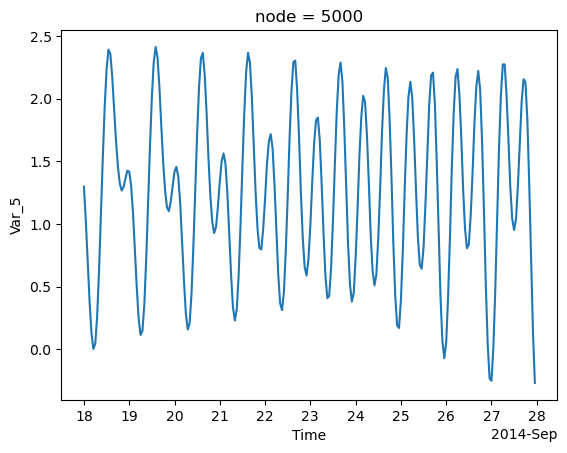

In [6]:
tide.sel(node=5000).plot()

Here's where we do the regridding. We're doing ten days, hourly (240 hours total == 240 regridding operations). This takes about 20 minutes to run single-threaded.

In [7]:
doxg_303d = []
for t in doxg.coords['Time']:
    print(t)
    gdf_tce_temp = gpd.GeoDataFrame({
        'depth': gdf_tce['depth'] + tide.sel(Time=t)
    }, geometry=gdf_tce['geometry'], crs=gdf_tce.crs, index=gdf_tce.index)
    regridder = calc_noncompliance.Regridder(gdf_tce_temp, gdf_303d, newgrid_mapping, 'tce', 'id_303d')
    doxg_303d.append(regridder.regrid(doxg.sel(Time=t).reset_coords('Time', drop=True)))
newcoords = doxg_303d[0].coords.copy()
newcoords['Time'] = doxg.coords['Time']
doxg_303d = xr.DataArray(doxg_303d, dims=['Time'] + list(doxg_303d[0].dims), coords=newcoords)

<xarray.DataArray 'Time' ()> Size: 8B
array('2014-09-18T00:00:00.000000', dtype='datetime64[us]')
Coordinates:
    Time     datetime64[us] 8B 2014-09-18
<xarray.DataArray 'Time' ()> Size: 8B
array('2014-09-18T01:00:00.000000', dtype='datetime64[us]')
Coordinates:
    Time     datetime64[us] 8B 2014-09-18T01:00:00
<xarray.DataArray 'Time' ()> Size: 8B
array('2014-09-18T02:00:00.000000', dtype='datetime64[us]')
Coordinates:
    Time     datetime64[us] 8B 2014-09-18T02:00:00
<xarray.DataArray 'Time' ()> Size: 8B
array('2014-09-18T03:00:00.000000', dtype='datetime64[us]')
Coordinates:
    Time     datetime64[us] 8B 2014-09-18T03:00:00
<xarray.DataArray 'Time' ()> Size: 8B
array('2014-09-18T04:00:00.000000', dtype='datetime64[us]')
Coordinates:
    Time     datetime64[us] 8B 2014-09-18T04:00:00
<xarray.DataArray 'Time' ()> Size: 8B
array('2014-09-18T05:00:00.000000', dtype='datetime64[us]')
Coordinates:
    Time     datetime64[us] 8B 2014-09-18T05:00:00
<xarray.DataArray 'Time' ()> Size: 8B

In [9]:
doxg_303d = xr.DataArray(doxg_303d, dims=['Time'] + list(doxg_303d[0].dims), coords=newcoords)
doxg_303d

<xarray.DataArray (Time: 240, siglay: 10, id_303d: 8224)> Size: 158MB
array([[[ 9.74577179,  9.64294049,  9.85271289, ..., 10.48999977,
         10.48999977, 10.05658082],
        [ 9.68241206,  9.65807218,  9.69668323, ...,  4.60296011,
          4.60296011,  4.41755343],
        [ 9.53723156,  9.62616632,  9.30193486, ...,  4.71397018,
          4.71397018,  4.68177161],
        ...,
        [ 9.43200529,  9.35785769,  9.35252037, ...,  2.85195994,
          2.85195994,  2.82414399],
        [ 9.34229914,  9.22978235,  9.34815086, ...,  2.70694995,
          2.70694995,  2.69138598],
        [ 8.85412892,  8.88610208,  8.81279242, ...,  2.52321005,
          2.52321005,  2.48869521]],

       [[ 9.73151842,  9.66297974,  9.78264754, ..., 10.33650017,
         10.33650017, 10.0687299 ],
        [ 9.65506436,  9.67254443,  9.61678917, ...,  4.4637599 ,
          4.4637599 ,  4.45322065],
        [ 9.54786978,  9.64398465,  9.27383895, ...,  4.64975023,
          4.64975023,  4.67169135],
...
        [ 7.99646394,  8.18190948,  7.66266196, ...,  2.8917799 ,
          2.8917799 ,  2.8714166 ],
        [ 7.98791866,  8.17350544,  7.65297483, ...,  2.73660994,
          2.73660994,  2.72114601],
        [ 7.97667647,  8.16311321,  7.63952556, ...,  2.56172991,
          2.56172991,  2.53497642]],

       [[ 8.19092048,  8.3725707 ,  7.80511002, ...,  8.76134014,
          8.76134014,  8.79162095],
        [ 8.19061775,  8.37236881,  7.804457  , ...,  5.83994007,
          5.83994007,  5.83773577],
        [ 8.18962653,  8.37167476,  7.80262295, ...,  4.39535999,
          4.39535999,  4.40028081],
        ...,
        [ 8.15995682,  8.34533459,  7.77091491, ...,  2.84658003,
          2.84658003,  2.84762488],
        [ 8.15158112,  8.33830396,  7.76084138, ...,  2.70945001,
          2.70945001,  2.71129095],
        [ 8.14036507,  8.32925867,  7.74652991, ...,  2.54965997,
          2.54965997,  2.53108643]]], shape=(240, 10, 8224))
Coordinates:
  * Time     (Time) datetime64[us] 2kB 2014-09-18 ... 2014-09-27T23:00:00
  * siglay   (siglay) int64 80B 1 2 3 4 5 6 7 8 9 10
  * id_303d  (id_303d) object 66kB '47122A9I7' '47122A9I8' ... '48124E8B0'

Let's start by plotting the time series for the cell we want to examine.

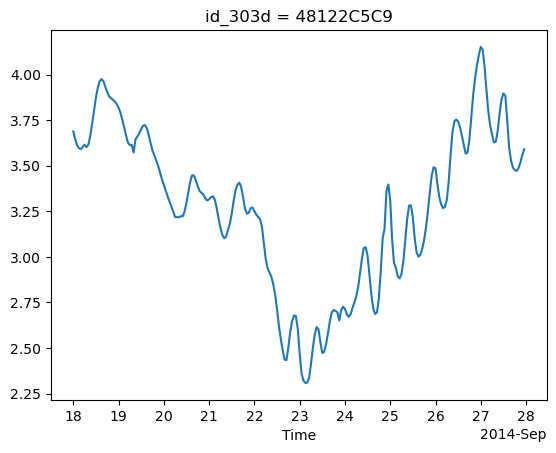

In [10]:
doxg_303d.sel(id_303d='48122C5C9').min(dim='siglay').plot()

It looks promising, let's calculate the minimum.

In [12]:
doxg_303d.sel(id_303d='48122C5C9').min(dim='siglay').min()

<xarray.DataArray ()> Size: 8B
array(2.30841736)
Coordinates:
    id_303d  <U9 36B '48122C5C9'

**That's Ecology's DOmin for the cell!** So it is possible to reproduce their numbers. Let's take a closer look at what makes up this cell.

In [14]:
newgrid_mapping.loc[newgrid_mapping['id_303d'] == '48122C5C9']

,id_303d,tce,shape_Area
OID_,,,
11659,48122C5C9,8583,145297.576883
11660,48122C5C9,8670,333483.678608
11661,48122C5C9,8671,327738.904573
11662,48122C5C9,8760,19106.785664


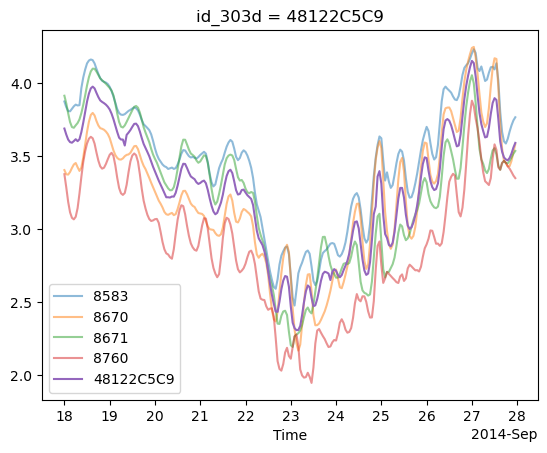

In [18]:
fig, ax = plt.subplots()
for idx,node in newgrid_mapping.loc[newgrid_mapping['id_303d'] == '48122C5C9', 'tce'].items():
    doxg.sel(node=node).min(dim='siglay').plot(ax=ax, label=node, alpha=0.5)
doxg_303d.sel(id_303d='48122C5C9').min(dim='siglay').plot(ax=ax, label='48122C5C9')
ax.legend()

Okay now it's clear what's happening. The above plot depicts the DO timeseries of the 303(d) cell in dark purple, and DO of the TCEs that make up that cell in lighter colors. On 9/23 it looks like all TCEs hit their minimum but they do so at different points in the tide cycle. Our approximations average all the TCE daily DOmins together which gives us a lower DOmin, enough to make our number not round to Ecology's.

The only way I see to address this is to perform a special 303(d) grid extraction from the model outputs themselves that works with hourly data. We'll end up needing 8760 total regrid operations per model run.